In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

print("Dataset Loaded ✅")
print(df.head())
print(df.columns)

# Remove missing values
df = df.dropna()

# =========================
# 3. FIX COLUMN NAMES
# =========================
df.columns = ['review', 'sentiment']

# =========================
# 4. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text)
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text

df['review'] = df['review'].apply(clean_text)

# =========================
# 5. CONVERT LABELS
# =========================
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print("\nSentiment Count:")
print(df['sentiment'].value_counts())

# =========================
# 6. TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

# =========================
# 8. BUILD MODEL
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
)

# Model Summary
model.summary()

# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================
# 10. PLOT GRAPH
# =========================
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# =========================
# 11. FINAL ACCURACY
# =========================
loss, accuracy = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", accuracy)

# =========================
# 12. PREDICTION ON NEW REVIEW
# =========================
sample_review = "This movie was absolutely fantastic and amazing!"

# Clean review
sample_review = clean_text(sample_review)

# Convert to TF-IDF
sample_vector = vectorizer.transform([sample_review]).toarray()

# Predict
prediction = model.predict(sample_vector)

if prediction[0][0] > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😢")

Dataset Loaded ✅
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')

Sentiment Count:
sentiment
1    25000
0    25000
Name: count, dtype: int64


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 128)                 │         640,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8657 - loss: 0.3116 - val_accuracy: 0.8839 - val_loss: 0.2697
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9049 - loss: 0.2308 - val_accuracy: 0.8884 - val_loss: 0.2699
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9271 - loss: 0.1813 - val_accuracy: 0.8849 - val_loss: 0.2948
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9698 - loss: 0.0857 - val_accuracy: 0.8812 - val_loss: 0.4033
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9944 - loss: 0.0215 - val_accuracy: 0.8765 - val_loss: 0.5612
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9997 - loss: 0.0031 - val_accuracy: 0.8745 - val_loss: 0.7655
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9999 - loss: 8.6636e-04 - val_accuracy: 0.8782 - val_loss: 0.8402
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 1.00

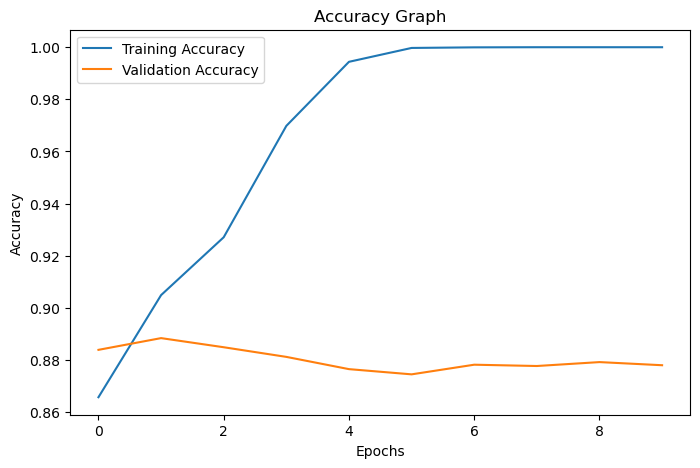

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8780 - loss: 1.0581

Final Accuracy: 0.878000020980835
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Actual vs Predicted Sentiment:

Review 1
Actual   : Positive 😊
Predicted: Negative 😢
Prediction Value: 0.0
--------------------------------------------------
Review 2
Actual   : Positive 😊
Predicted: Positive 😊
Prediction Value: 1.0
--------------------------------------------------
Review 3
Actual   : Negative 😢
Predicted: Negative 😢
Prediction Value: 0.0
--------------------------------------------------
Review 4
Actual   : Positive 😊
Predicted: Positive 😊
Prediction Value: 1.0
--------------------------------------------------
Review 5
Actual   : Negative 😢
Predicted: Negative 😢
Prediction Value: 0.0
--------------------------------------------------
Review 6
Actual   : Positive 😊
Predicted: Positive 😊
Prediction Value: 1.0
--------------------------------------------------
Review 7
Actual   : Positive 😊
Predicted: Positive 😊
Predict

In [4]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

print("Dataset Loaded ✅")
print(df.head())
print(df.columns)

# Remove missing values
df = df.dropna()

# =========================
# 3. FIX COLUMN NAMES
# =========================
df.columns = ['review', 'sentiment']

# =========================
# 4. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text)
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text

df['review'] = df['review'].apply(clean_text)

# =========================
# 5. CONVERT LABELS
# =========================
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print("\nSentiment Count:")
print(df['sentiment'].value_counts())

# =========================
# 6. TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

# =========================
# 8. BUILD MODEL
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
)

# Model Summary
model.summary()

# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================
# 10. PLOT GRAPH
# =========================
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# =========================
# 11. FINAL ACCURACY
# =========================
loss, accuracy = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", accuracy)

# =========================
# =========================
# 12. PREDICTIONS ON TEST DATA
# =========================

predictions = model.predict(X_test)

print("\nActual vs Predicted Sentiment:\n")

for i in range(10):

    # Convert probability into class
    predicted_label = 1 if predictions[i][0] > 0.5 else 0

    # Convert numeric labels to text
    predicted_sentiment = "Positive 😊" if predicted_label == 1 else "Negative 😢"

    actual_sentiment = "Positive 😊" if y_test.iloc[i] == 1 else "Negative 😢"

    print(f"Review {i+1}")
    print("Actual   :", actual_sentiment)
    print("Predicted:", predicted_sentiment)
    print("Prediction Value:", round(predictions[i][0], 2))
    print("-" * 50)